<a href="https://colab.research.google.com/github/yaswanth-AIML/ml_in_Python/blob/main/car_evalution_desicion_tress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [164]:
data=pd.read_csv('/content/car.data')

In [165]:
data.shape

(1727, 7)

In [166]:
data

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [167]:
data.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'low', 'unacc'], dtype='object')

In [168]:
columns=["buying","maint","doors","persons","Lug_boot","saftey","target"]

In [169]:
df=pd.read_csv("/content/car.data",names=columns)

In [170]:
df.shape

(1728, 7)

In [171]:
df

,buying,maint,doors,persons,Lug_boot,saftey,target
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


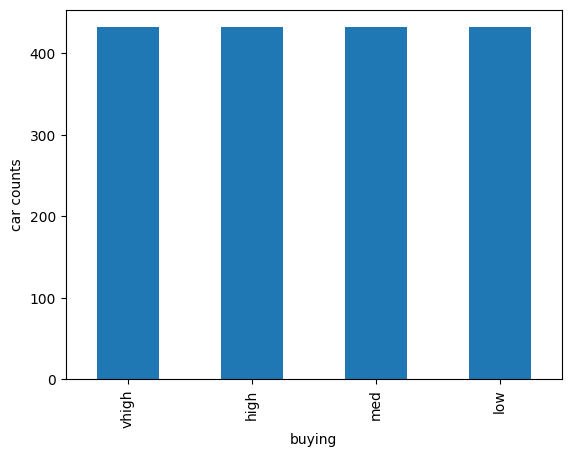

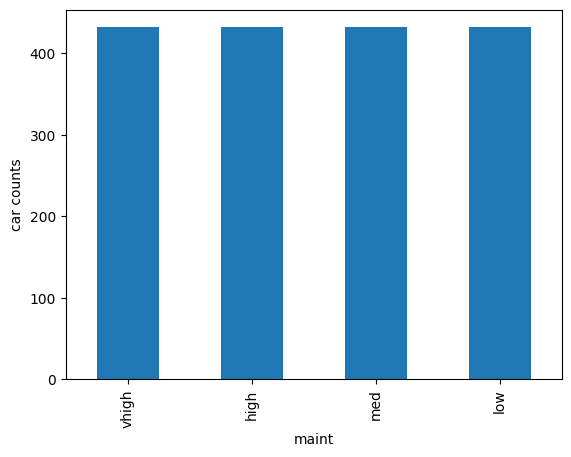

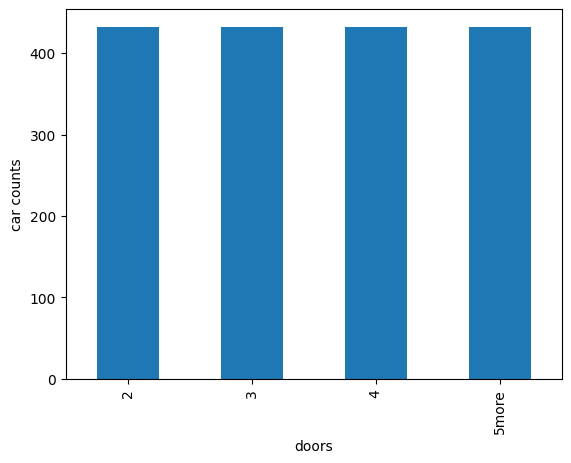

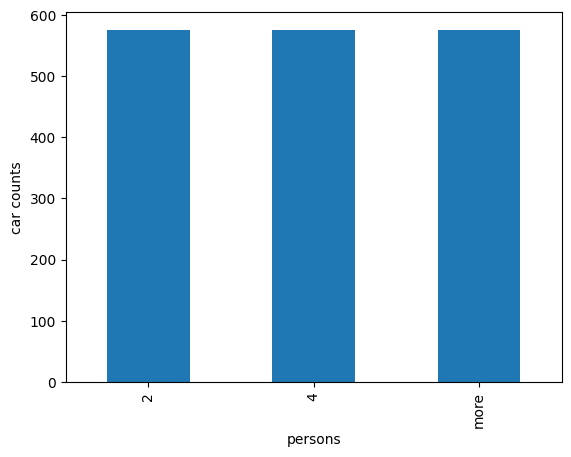

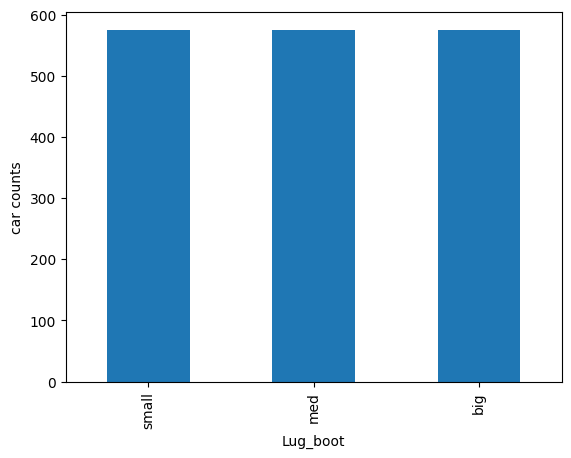

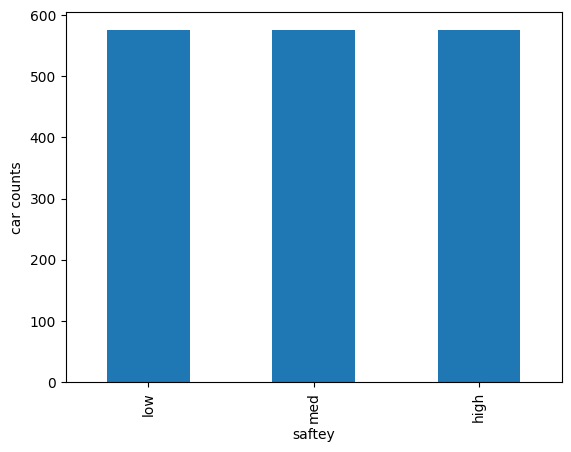

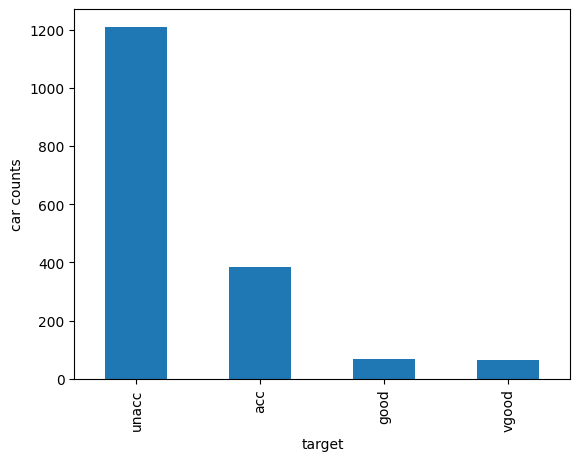

In [172]:
for i in columns:
  df[i].value_counts().plot(kind='bar')
  plt.xlabel(i)
  plt.ylabel('car counts')
  plt.show()

In [173]:
df.columns

Index(['buying', 'maint', 'doors', 'persons', 'Lug_boot', 'saftey', 'target'], dtype='object')

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   Lug_boot  1728 non-null   object
 5   saftey    1728 non-null   object
 6   target    1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [175]:
df.describe()

,buying,maint,doors,persons,Lug_boot,saftey,target
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [176]:
for i in columns:
  print(i,df[i].unique())

buying ['vhigh' 'high' 'med' 'low']
maint ['vhigh' 'high' 'med' 'low']
doors ['2' '3' '4' '5more']
persons ['2' '4' 'more']
Lug_boot ['small' 'med' 'big']
saftey ['low' 'med' 'high']
target ['unacc' 'acc' 'vgood' 'good']


In [177]:
map1 = {
    "buying":  {"vhigh": 4, "high": 3, "med": 2, "low": 1},
    "maint":  {"vhigh": 4, "high": 3, "med": 2, "low": 1},
    "doors":  {"2": 1, "3": 2, "4": 3, "5more": 4},
    "persons":{"2": 1, "4": 2, "more": 3},
    "Lug_boot":{"small": 1, "med": 2, "big": 3},
    "saftey": {"low": 1, "med": 2, "high": 3},
    "target": {"unacc": 1, "acc": 2, "good": 3, "vgood": 4}
}

In [178]:
for i in map1:
  df[i]=df[i].map(map1[i])

In [179]:
df.head(10)

,buying,maint,doors,persons,Lug_boot,saftey,target
0,4,4,1,1,1,1,1
1,4,4,1,1,1,2,1
2,4,4,1,1,1,3,1
3,4,4,1,1,2,1,1
4,4,4,1,1,2,2,1
5,4,4,1,1,2,3,1
6,4,4,1,1,3,1,1
7,4,4,1,1,3,2,1
8,4,4,1,1,3,3,1
9,4,4,1,2,1,1,1


In [180]:
for i in columns:
  print(i,df[i].unique())

buying [4 3 2 1]
maint [4 3 2 1]
doors [1 2 3 4]
persons [1 2 3]
Lug_boot [1 2 3]
saftey [1 2 3]
target [1 2 4 3]


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int64
 1   maint     1728 non-null   int64
 2   doors     1728 non-null   int64
 3   persons   1728 non-null   int64
 4   Lug_boot  1728 non-null   int64
 5   saftey    1728 non-null   int64
 6   target    1728 non-null   int64
dtypes: int64(7)
memory usage: 94.6 KB


In [182]:
df.describe()

,buying,maint,doors,persons,Lug_boot,saftey,target
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,2.500000,2.500000,2.500000,2.000000,2.000000,2.000000,1.414931
std,1.118358,1.118358,1.118358,0.816733,0.816733,0.816733,0.740700
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.750000,1.750000,1.750000,1.000000,1.000000,1.000000,1.000000
50%,2.500000,2.500000,2.500000,2.000000,2.000000,2.000000,1.000000
75%,3.250000,3.250000,3.250000,3.000000,3.000000,3.000000,2.000000
max,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,4.000000


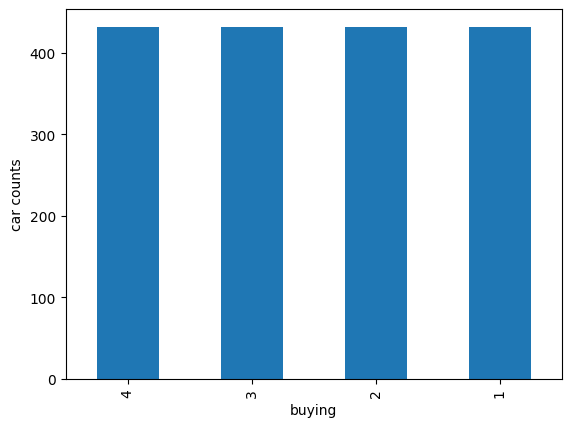

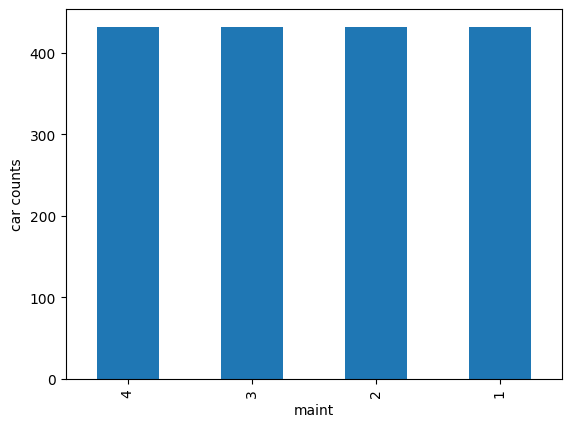

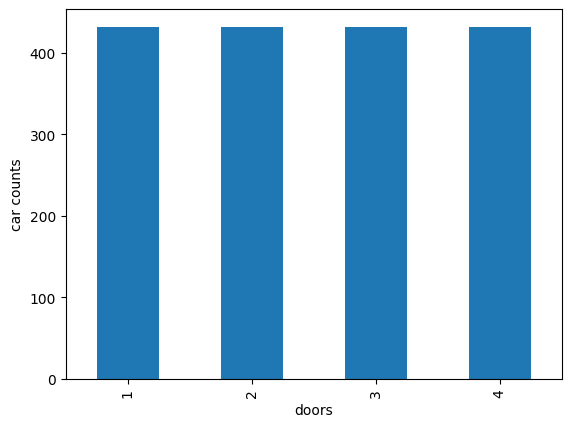

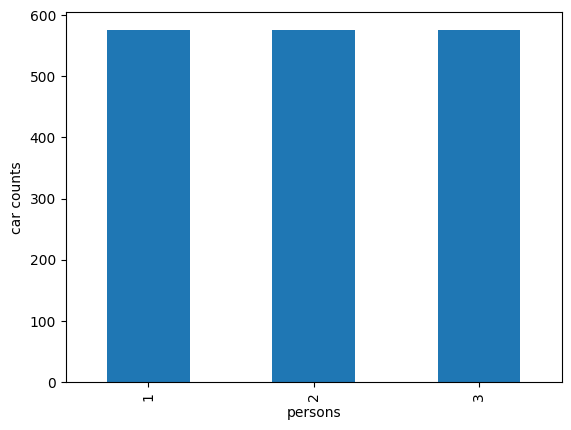

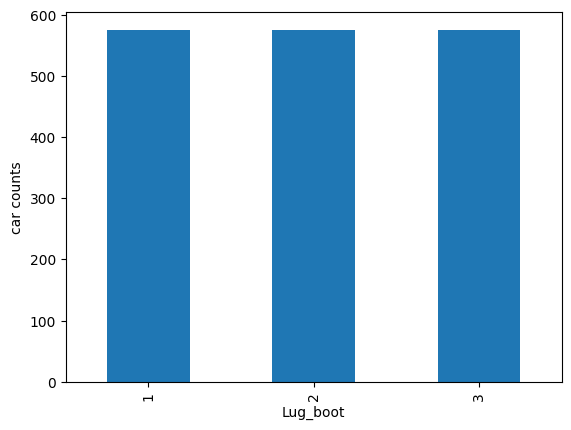

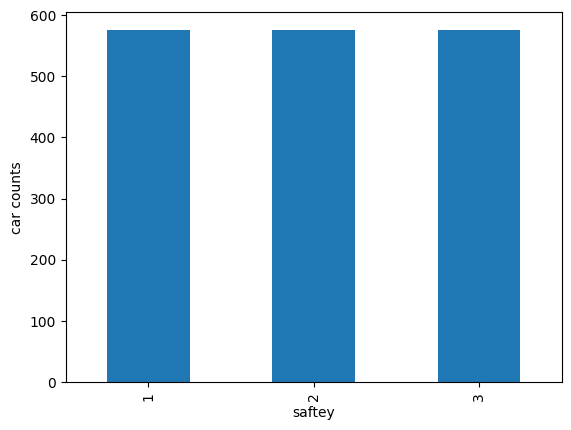

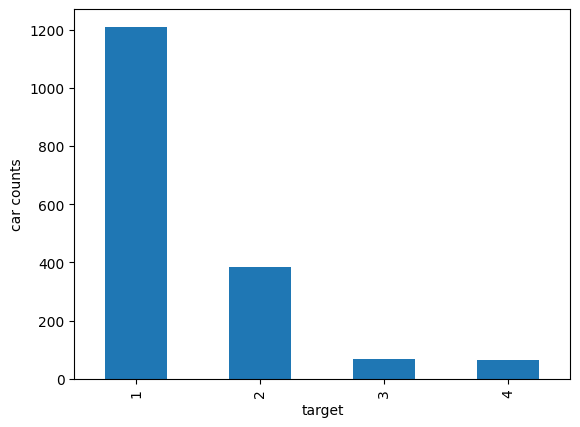

In [183]:
for i in columns:
  df[i].value_counts().plot(kind='bar')
  plt.xlabel(i)
  plt.ylabel('car counts')
  plt.show()

In [184]:
x=df.drop(columns=['target'])
y=df['target']

In [185]:
x

,buying,maint,doors,persons,Lug_boot,saftey
0,4,4,1,1,1,1
1,4,4,1,1,1,2
2,4,4,1,1,1,3
3,4,4,1,1,2,1
4,4,4,1,1,2,2
...,...,...,...,...,...,...
1723,1,1,4,3,2,2
1724,1,1,4,3,2,3
1725,1,1,4,3,3,1
1726,1,1,4,3,3,2


In [186]:
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
1723,3
1724,4
1725,1
1726,3


In [187]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=99)

In [188]:
model1=DecisionTreeClassifier(criterion="entropy")
model1.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [189]:
model2=DecisionTreeClassifier()
model2.fit(x_train,y_train)

DecisionTreeClassifier()

In [190]:
predictions1=model1.predict(x_test)
predictions2=model2.predict(x_test)

In [191]:
predictions1
predictions2

array([1, 2, 1, 2, 4, 2, 1, 1, 1, 4, 4, 2, 1, 3, 1, 1, 2, 1, 1, 2, 1, 2,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 4, 1, 1, 1, 2, 2, 1, 1, 2,
       1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 2, 2, 1, 1, 1, 1, 1, 4, 3, 1, 1, 2, 1, 1, 1, 1, 3, 2, 1, 1, 1,
       1, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 1, 1,
       3, 2, 2, 1, 1, 2, 3, 1, 2, 1, 4, 1, 2, 1, 2, 1, 2, 1, 3, 1, 1, 1,
       1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 1, 1, 3, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       4, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 4, 2, 4, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 4, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 4, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 3, 1, 1, 2, 1, 1, 2,
       2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2,

In [192]:
accuracy1=accuracy_score(predictions1,y_test)
accuracy2=accuracy_score(predictions2,y_test)

In [193]:
print(accuracy1)
print(accuracy2)

0.9745370370370371
0.9791666666666666


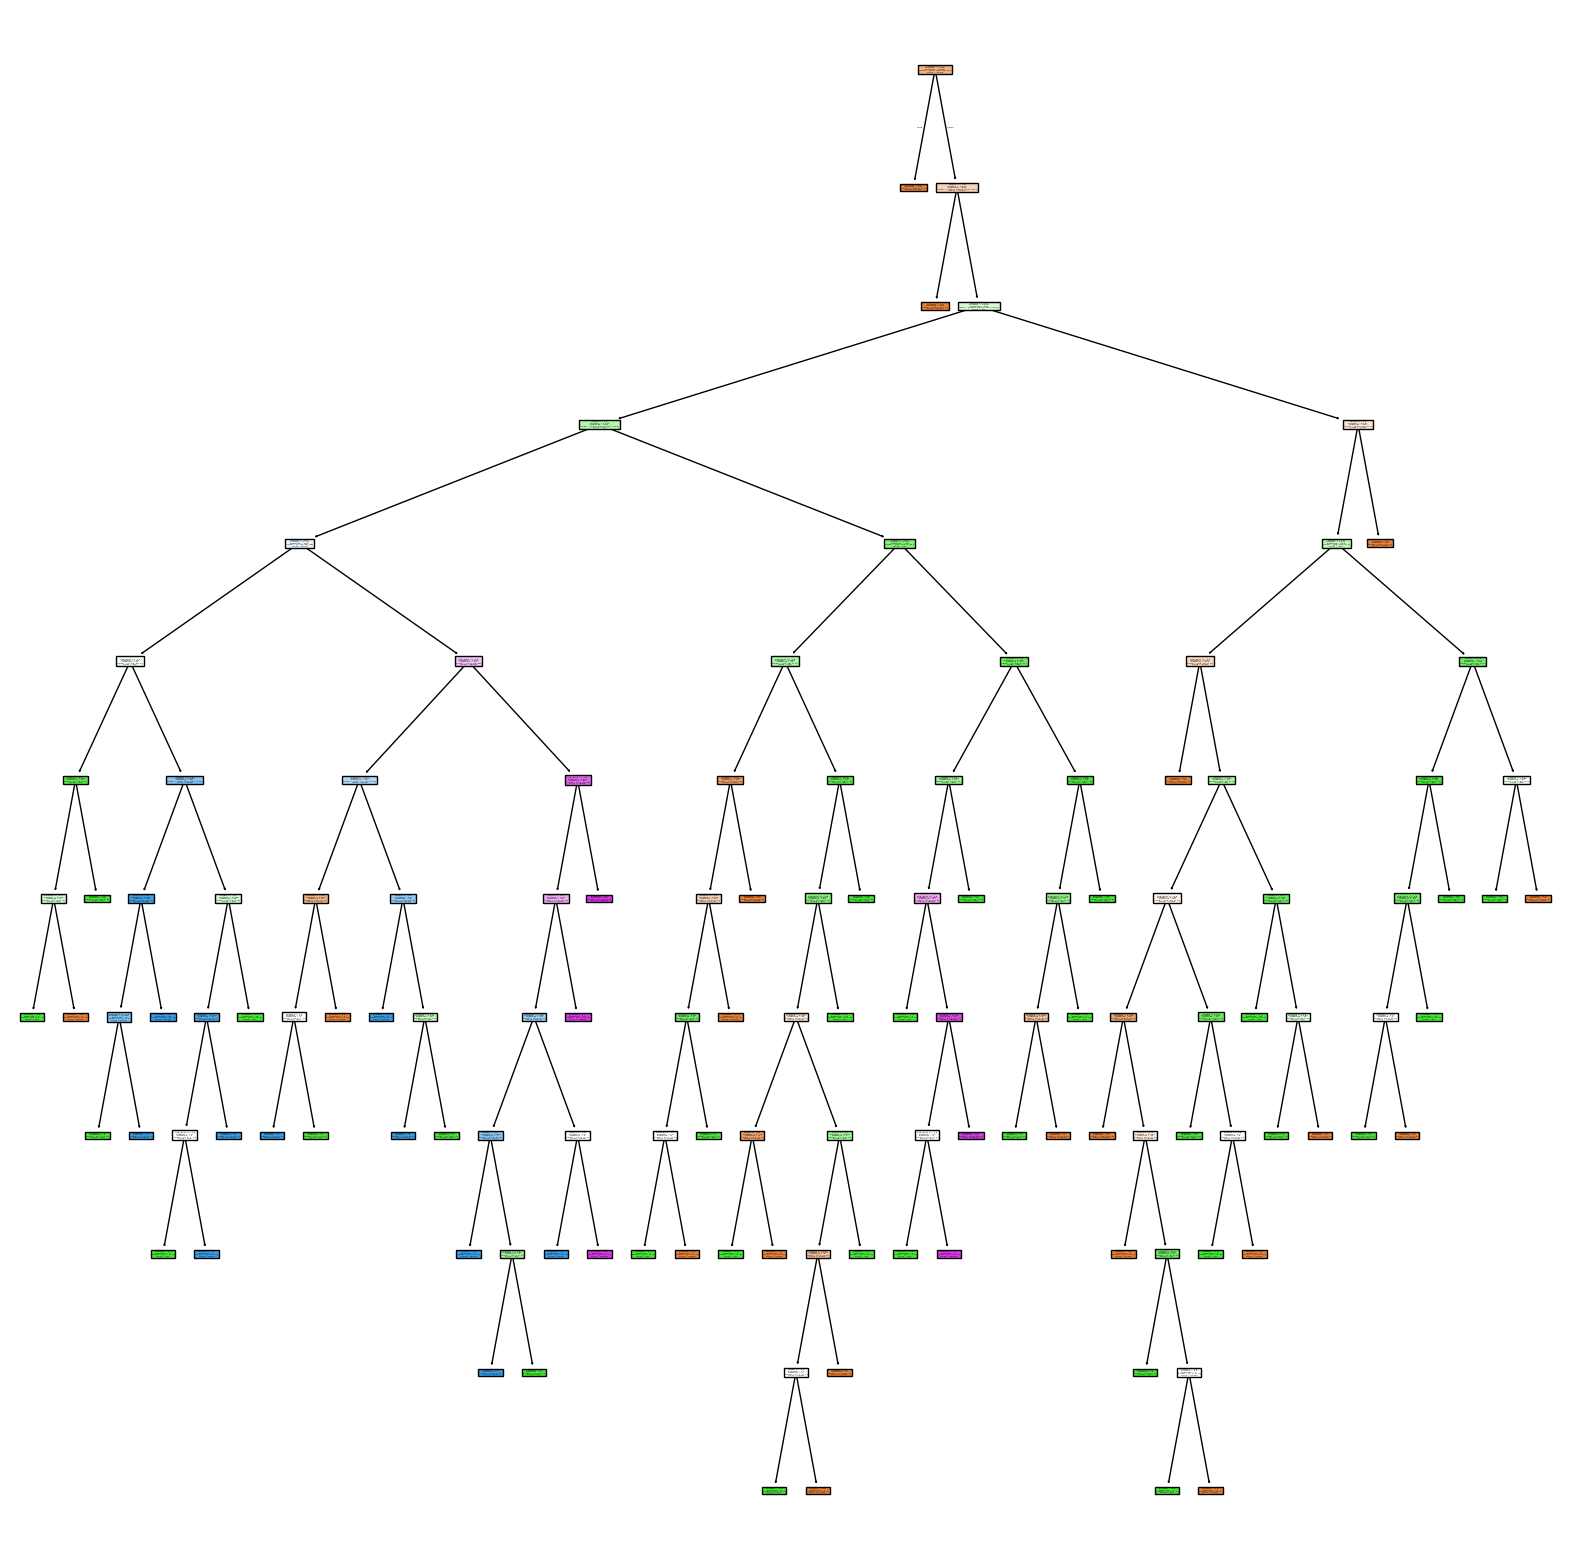

In [194]:
from sklearn import tree
plt.figure(figsize=(20,20))
tree.plot_tree(model1,feature_names=x.columns,class_names=["unacc","acc","good","vgood"],filled=True)
plt.show()

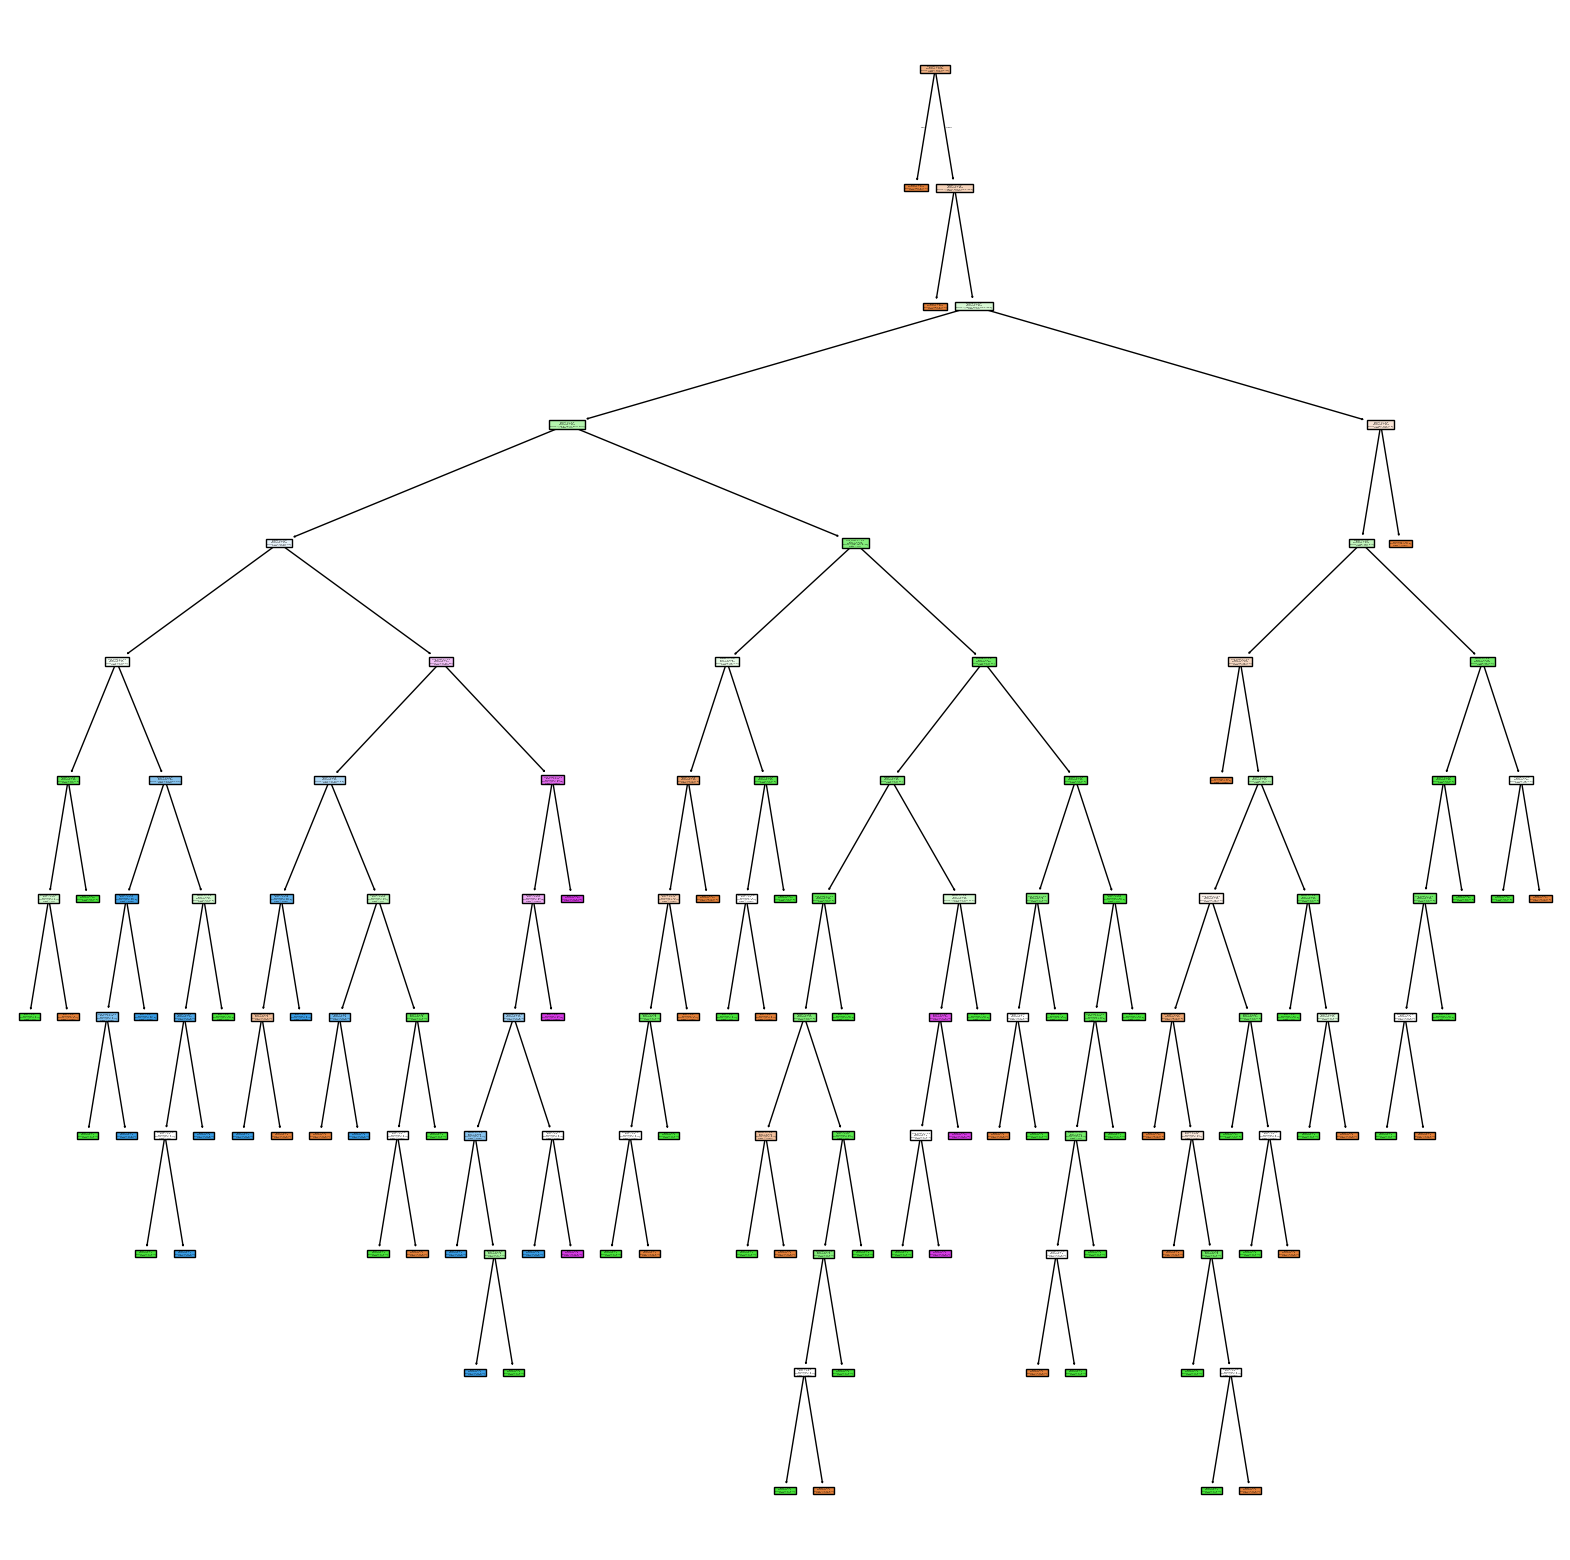

In [195]:
plt.figure(figsize=(20,20))
tree.plot_tree(model2,feature_names=x.columns,class_names=["unacc","acc","good","vgood"],filled=True)
plt.show()

In [196]:
maxi2=DecisionTreeClassifier(criterion='entropy',max_depth=2)
maxi5=DecisionTreeClassifier(criterion='entropy',max_depth=5)
maxi7=DecisionTreeClassifier(criterion="entropy",max_depth=7)
maxi10=DecisionTreeClassifier(criterion="entropy",max_depth=10)

In [197]:
maxi2.fit(x_train,y_train)
maxi5.fit(x_train,y_train)
maxi7.fit(x_train,y_train)
maxi10.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10)

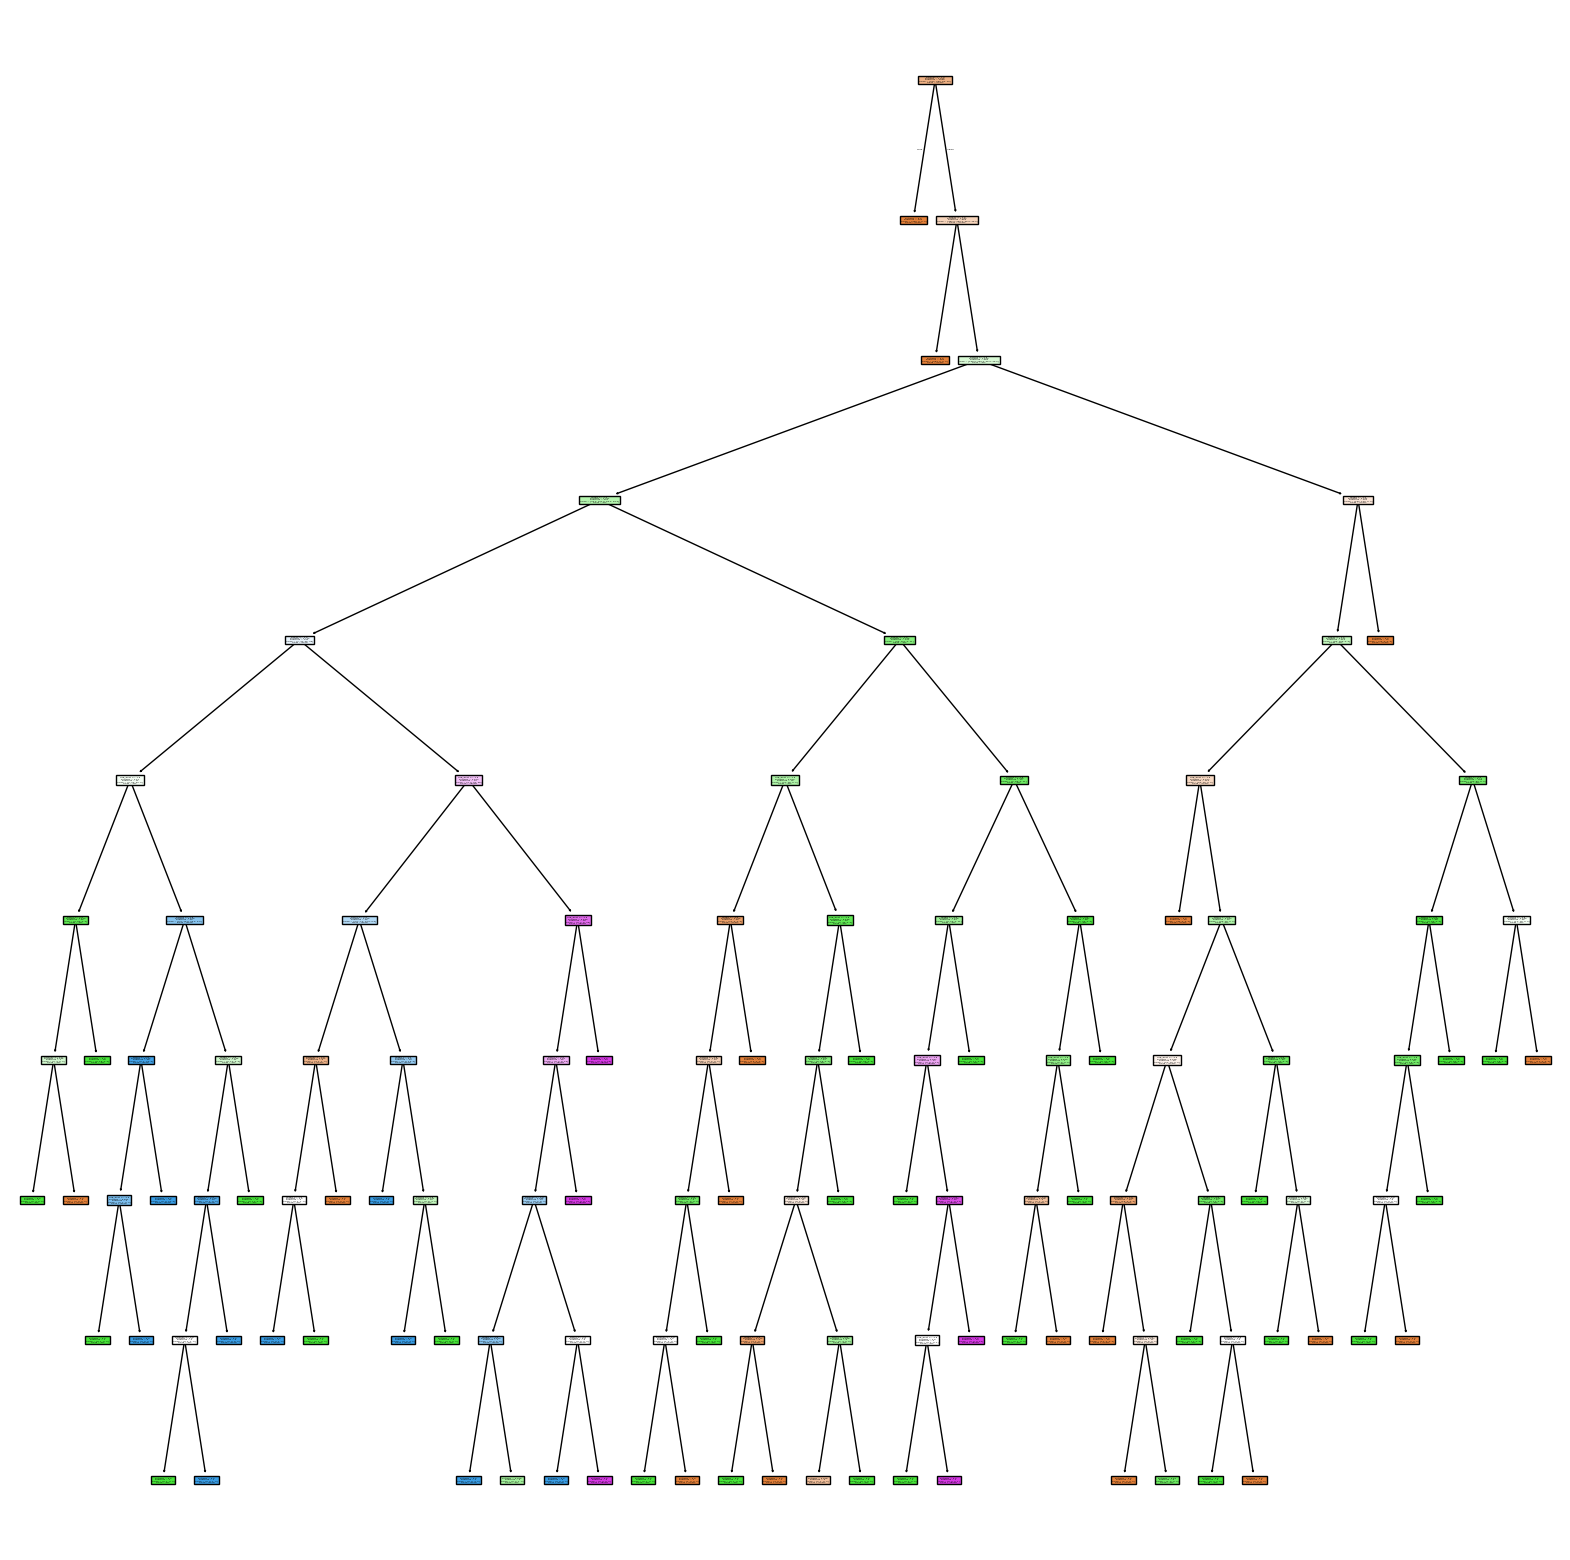

In [198]:
plt.figure(figsize=(20,20))
tree.plot_tree(maxi10,feature_names=x.columns,class_names=["unacc","acc","good","vgood"],filled=True)
plt.show()

In [199]:
y_pred2=maxi2.predict(x_test)
y_pred5=maxi5.predict(x_test)
y_pred7=maxi7.predict(x_test)
y_pred10=maxi10.predict(x_test)

In [200]:
y_accuracy2=accuracy_score(y_pred2,y_test)
y_accuracy5=accuracy_score(y_pred5,y_test)
y_accuracy7=accuracy_score(y_pred7,y_test)
y_accuracy10=accuracy_score(y_pred10,y_test)

In [201]:
print(y_accuracy2)
print(y_accuracy5)
print(y_accuracy5)
print(y_accuracy10)

0.8101851851851852
0.8726851851851852
0.8726851851851852
0.9675925925925926


In [202]:
model = DecisionTreeClassifier(ccp_alpha=0.01)
model.fit(x_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.01)

In [203]:
predict=model.predict(x_test)

In [204]:
accuracy=accuracy_score(predict,y_test)

In [205]:
print(accuracy)

0.9236111111111112


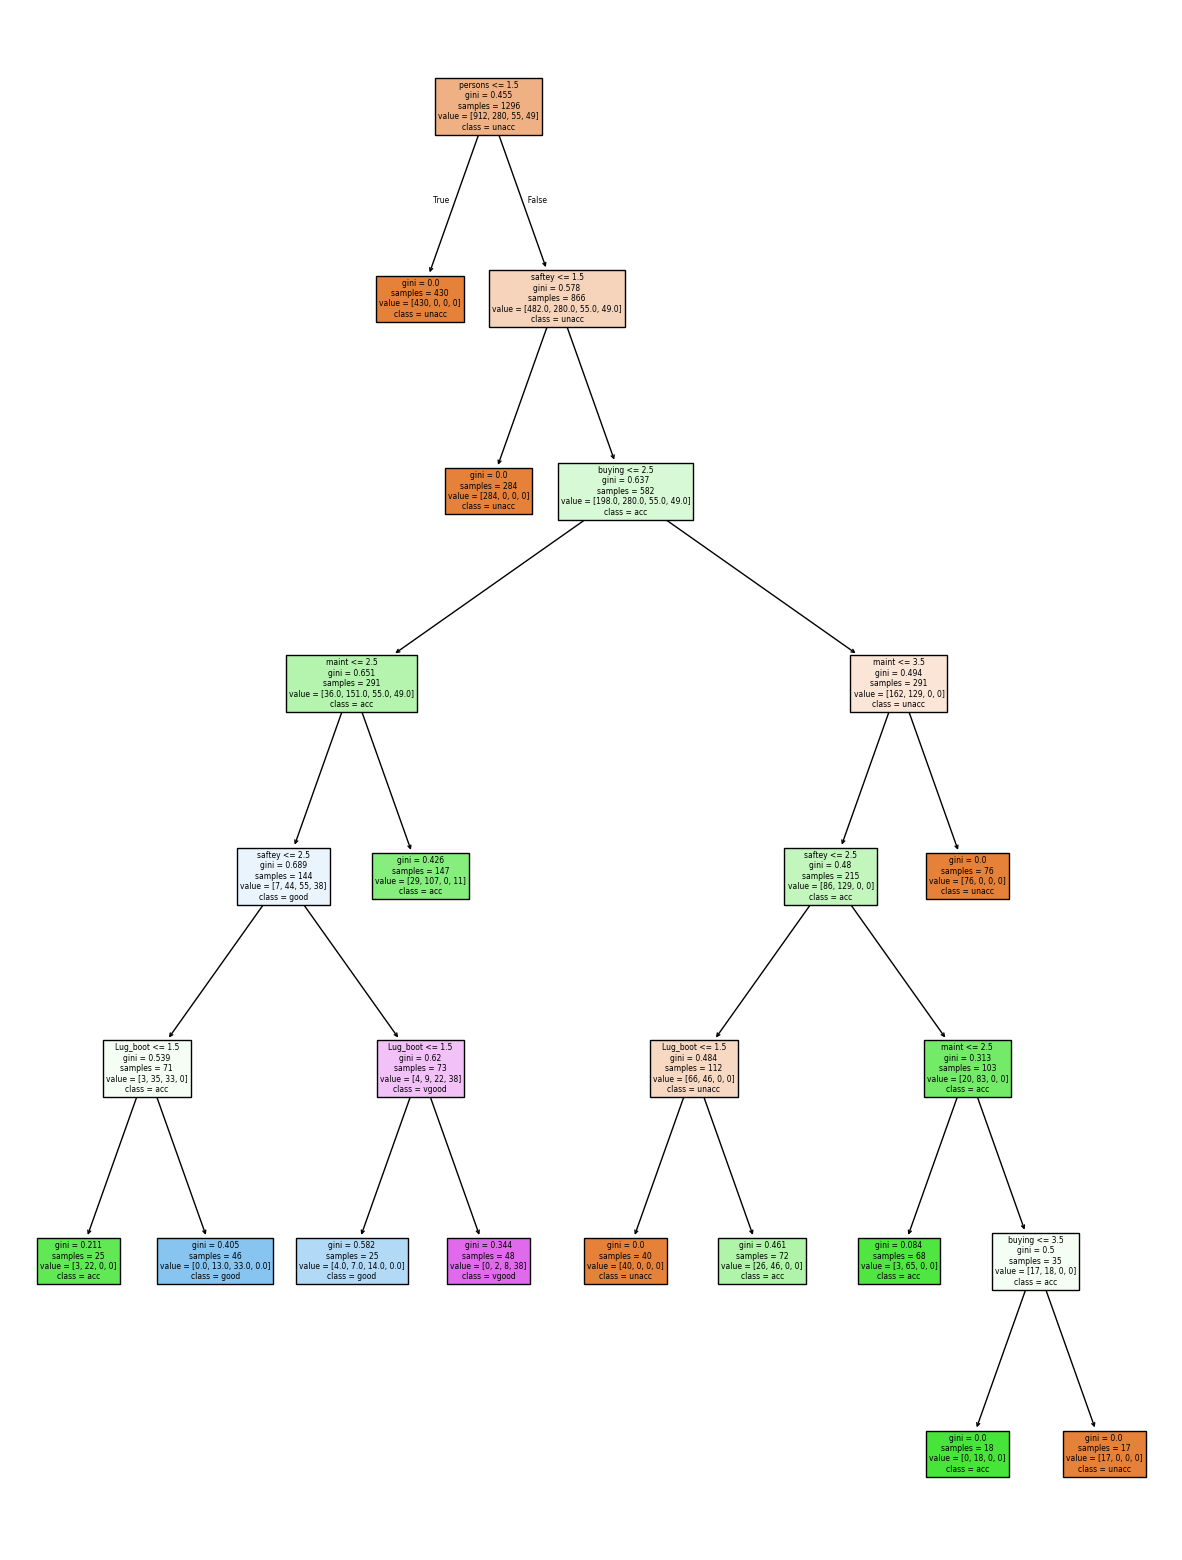

In [206]:
plt.figure(figsize=(15,20))
tree.plot_tree(model,feature_names=x.columns,class_names=["unacc","acc","good","vgood"],filled=True)
plt.show()

In [207]:
import pickle as pk
with open("decisio_tree_car_classifier.pkl","wb")as k:
  pk.dump(model,k)